## TP1 - Michel Jean Joseph Donnet

In [1]:
## Imports
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
# local fitness functions f_K for K = 0, 1, 2 (Table in TP)
f = {
    0: {
        '0': 2,
        '1': 1
    },
    1: { 
        '00': 2,
        '01': 3,
        '10': 2,
        '11': 0
    },
    2: {
        '000': 0,
        '001': 1,
        '010': 1,
        '011': 0,
        '100': 2,
        '101': 0,
        '110': 0,
        '111': 0
    }
}

In [3]:
def generate_sequence(N):
    # TODO
    '''
    generates an N random bits (0, 1) sequence

    Parameters:
    -----------
    N : number of bits in the sequence

    Returns:
    --------
    sequence: sequence of N bits
    '''
    sequence = ''
    for i in range(N):
        sequence += str(random.randint(0, 1))
    return sequence


def compute_fitness(sequence, K):
    # TODO
    '''
    computes the fitness of sequence, with respect to K, according to table f

    Parameters:
    -----------
    sequence : N-bits sequence
    K : parameter K (0, 1, or 2)

    Returns:
    --------
    fitness: fitness value of sequence
    '''
    fitness = 0
    for i in range(len(sequence) - K):
        fitness += f[K][sequence[i: i + K + 1]]
    return fitness

assert compute_fitness('0101', 0) == 6
assert compute_fitness('0101', 1) == 8
assert compute_fitness('0101', 2) == 1


def neighbors(sequence):
    ''' 
    returns all neighbors of sequence ()

    Parameters:
    -----------
    sequence : N-bits sequence

    Returns:
    --------
    generator of neighbors of sequence
    '''
    # generate all neighbors that differ in 1 bit 
    for i in range(len(sequence)):
        if sequence[i] == '0':
            new = '1'
        else: new = '0'
        yield (sequence[:i] + new + sequence[i + 1:])


def mean_steps(samples):
    ''' 
    returns mean of steps taken to find solution (for deterministic)

    Parameters:
    -----------
    samples : samples of deterministic_hillclimb runs

    Returns:
    --------
    mean steps
    '''
    # get mean of steps needed to find solution (sum of samples' steps/number of samples)
    return sum(x[2] for x in samples)/len(samples)


def generate_samples(hillclimb_method, K):
    ''' 
    generates 50 samples (solutions) for the hillclimb method (deterministic/probabilistic)

    Parameters:
    -----------
    hillclimb_method : deterministic_hillclimb/probabilistic_hillclimb
    K : parameter K (0, 1, or 2)

    Returns:
    --------
    generator of samples/solutions (sequence, fitness, number of steps)
    '''
    if K not in [0, 1, 2]:
        raise Exception("Invalid K")

    # run for 50 times to get 50 samples/solutions
    for i in range(50):
        # generate initial sequence
        initial_sequence = generate_sequence(N=21)
        # get solution, its fitness, number of steps taken to find solution
        x, f_x, s = hillclimb_method(initial_sequence, K)
        yield (x, f_x, s)

In [4]:
def deterministic_hillclimb(sequence, K):
    # TODO
    ''' 
    performs deterministic_hillclimb

    Parameters:
    -----------
    sequence : N-bits sequence
    K : parameter K (0, 1, or 2)

    Returns:
    --------
    sequence : optimal/fittest sequence found
    max_fitness : fitness value of sequence
    steps: steps it took to reach optimum 
    '''
    steps = 0
    current = sequence
    current_fitness = compute_fitness(sequence, K)
    cont = True
    while cont:
        steps += 1
        list_neighbors = list(neighbors(current))
        list_neighbors_fitness = [compute_fitness(n, K) for n in list_neighbors]
        if current_fitness >= max(list_neighbors_fitness):
            cont = False
        else:
            current = list_neighbors[np.argmax(list_neighbors_fitness)]
            current_fitness = max(list_neighbors_fitness)
    return current, current_fitness, steps

# dictionary to save deterministic_hillclimb samples (sequence, max_fitness, steps)
deterministic_samples = {}
# dictionary to save number of steps to perform probabilistic hillclimb 
probabilistic_steps = {}


# run deterministic_hillclimb, get mean steps
for K in [0, 1, 2]:
    # for each K, generate 50 deterministic_hillclimb solutions, and save them
    deterministic_samples[K] = list(generate_samples(deterministic_hillclimb, K))
    # for each K, save the number of steps to take (10*mean steps taken for deterministic_hillclimb)
    probabilistic_steps[K] = 10*round(mean_steps(deterministic_samples[K]))
    

In [5]:
def probabilistic_hillclimb(sequence, K):
    # TODO
    ''' 
    performs probabilistic_hillclimb

    Parameters:
    -----------
    sequence : N-bits sequence
    K : parameter K (0, 1, or 2)

    Returns:
    --------
    sequence : optimal/fittest sequence found
    max_fitness : fitness value of sequence
    steps: steps corresponding to parameter K
    '''
    best_sequence = []
    best_fitness = []
    step_number = 10 * probabilistic_steps[K]
    current = sequence
    current_fitness = compute_fitness(current, K)
    for i in range(step_number):
        list_neighbors = list(neighbors(current))
        list_neighbors_fitness = np.array([compute_fitness(j, K) for j in list_neighbors])
        P_fitness = list_neighbors_fitness / np.sum(list_neighbors_fitness)
        current = random.choices(list_neighbors, weights = P_fitness, k = 1)[0]

        best_fitness.append(max(list_neighbors_fitness))
        best_sequence.append(list_neighbors[np.argmax(list_neighbors_fitness)])

    result_fitness = max(best_fitness)
    result_sequence = best_sequence[np.argmax(best_fitness)]

    return result_sequence, result_fitness, step_number
    
    


# dictionary to save probabilistic_hillclimb samples (sequence, max_fitness, steps)
probabilistic_samples = {}


# run probabilistic_hillclimb
for K in [0, 1, 2]:
    # for each K, generate 50 probabilistic_hillclimb solutions, and save them
    probabilistic_samples[K] = list(generate_samples(probabilistic_hillclimb, K))

In [6]:
def hamming_distance(sequence1, sequence2):
    # TODO
    ''' 
    returns hamming distance between sequence1 and sequence2

    Parameters:
    -----------
    sequence1 : N-bits sequence
    sequence2 : N-bits sequence

    Returns:
    --------
    distance : hamming distance between sequence1 and sequence2
    '''
    if len(sequence1) != len(sequence2):
        print("Error ! Sequences must have the same length !")
        return -1
    result = 0
    for i in range(len(sequence1)):
        if sequence1[i] != sequence2[i]:
            result += 1
    return result

assert hamming_distance('0101', '0101') == 0

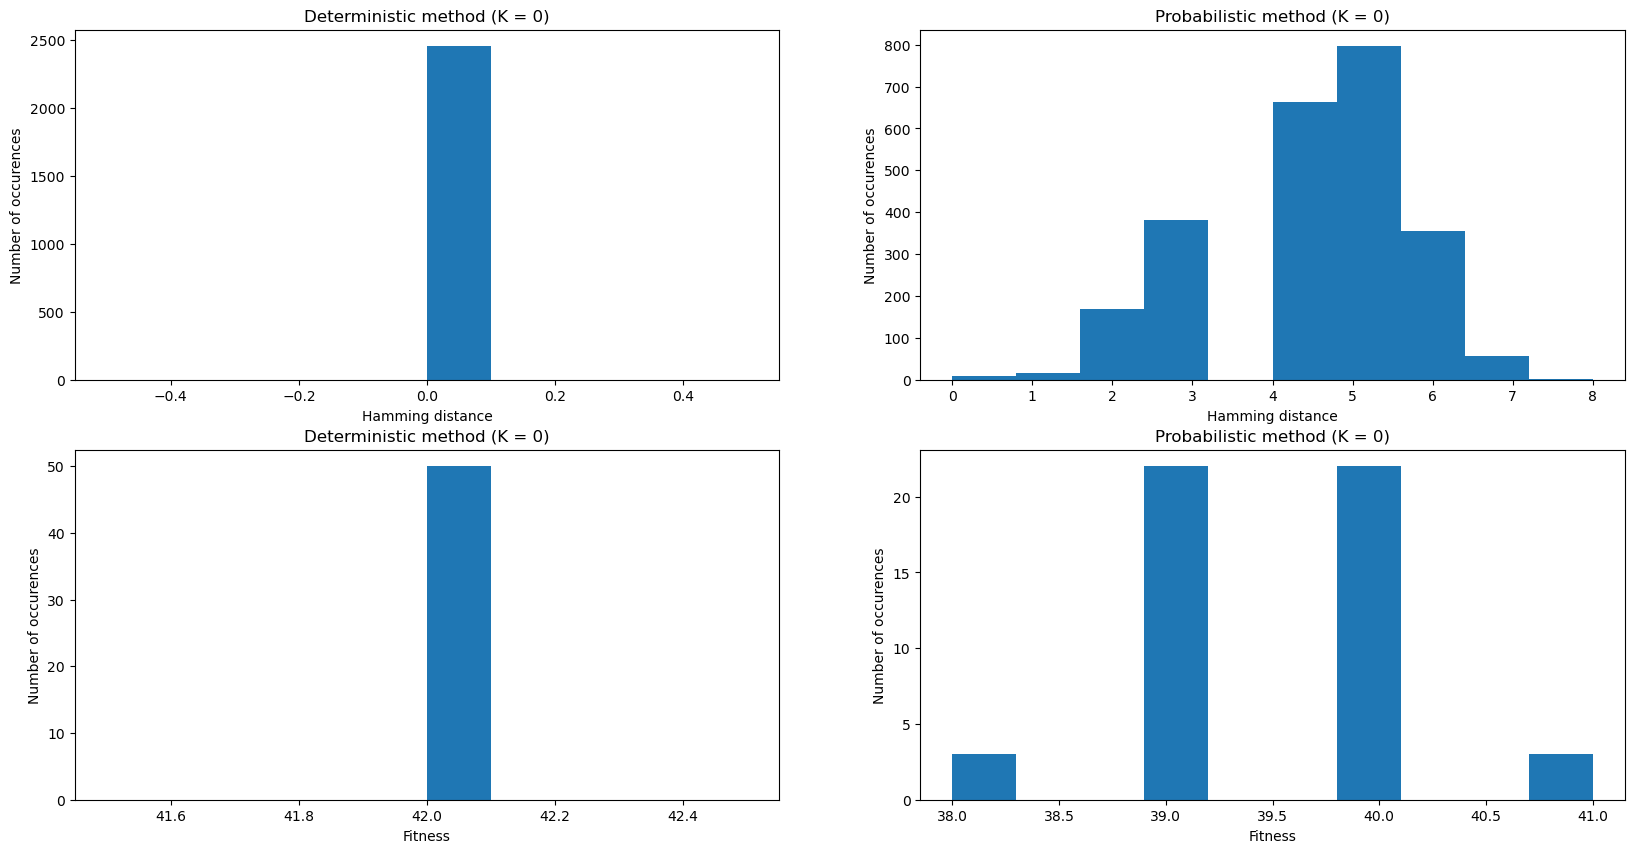

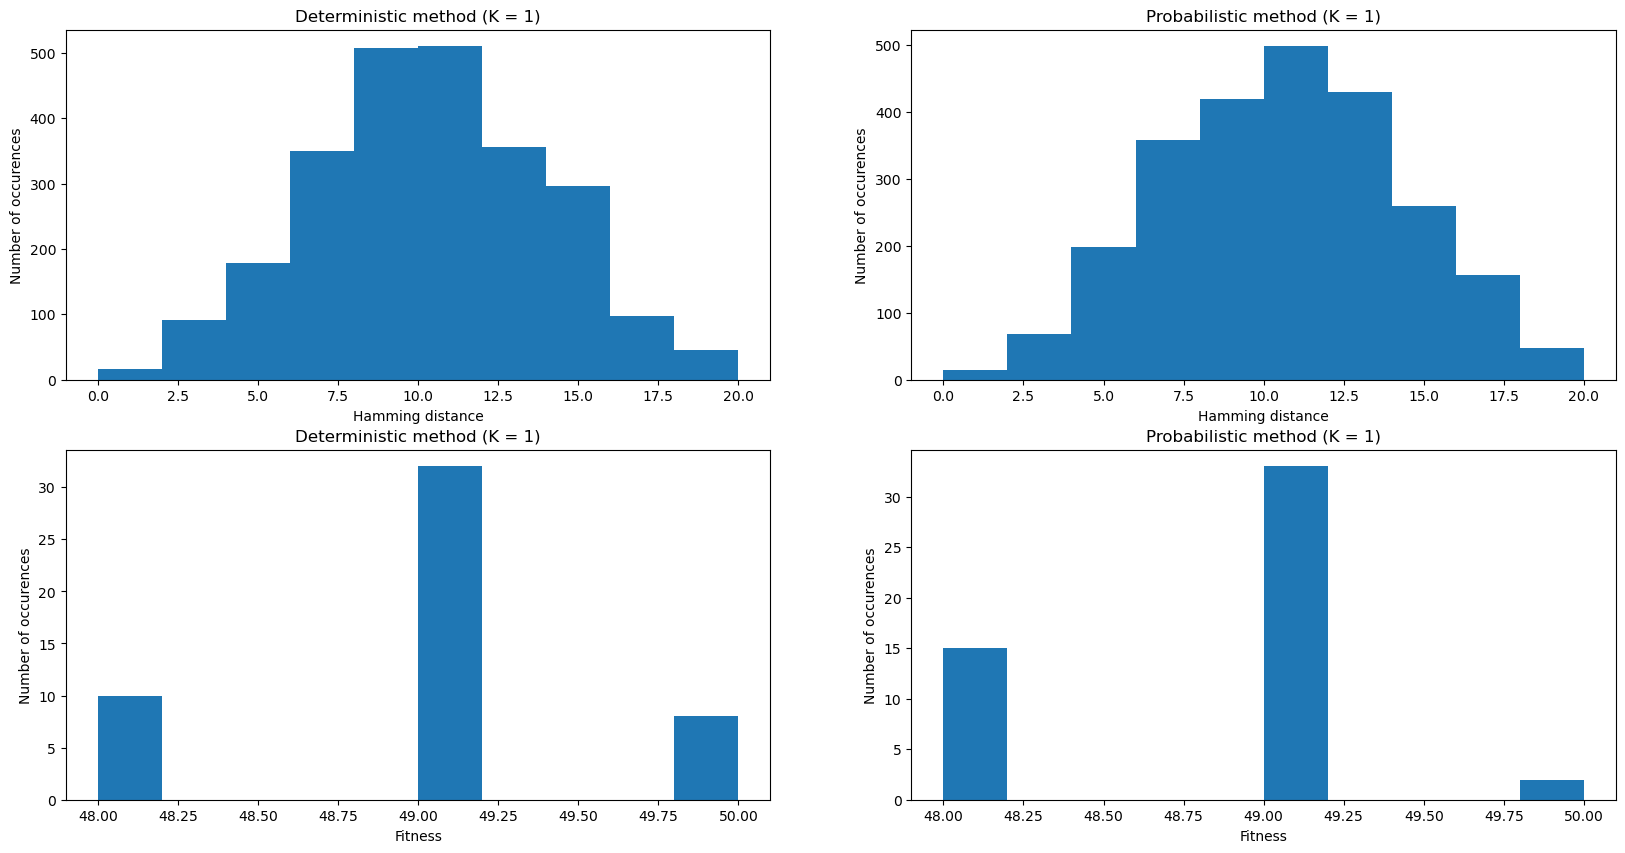

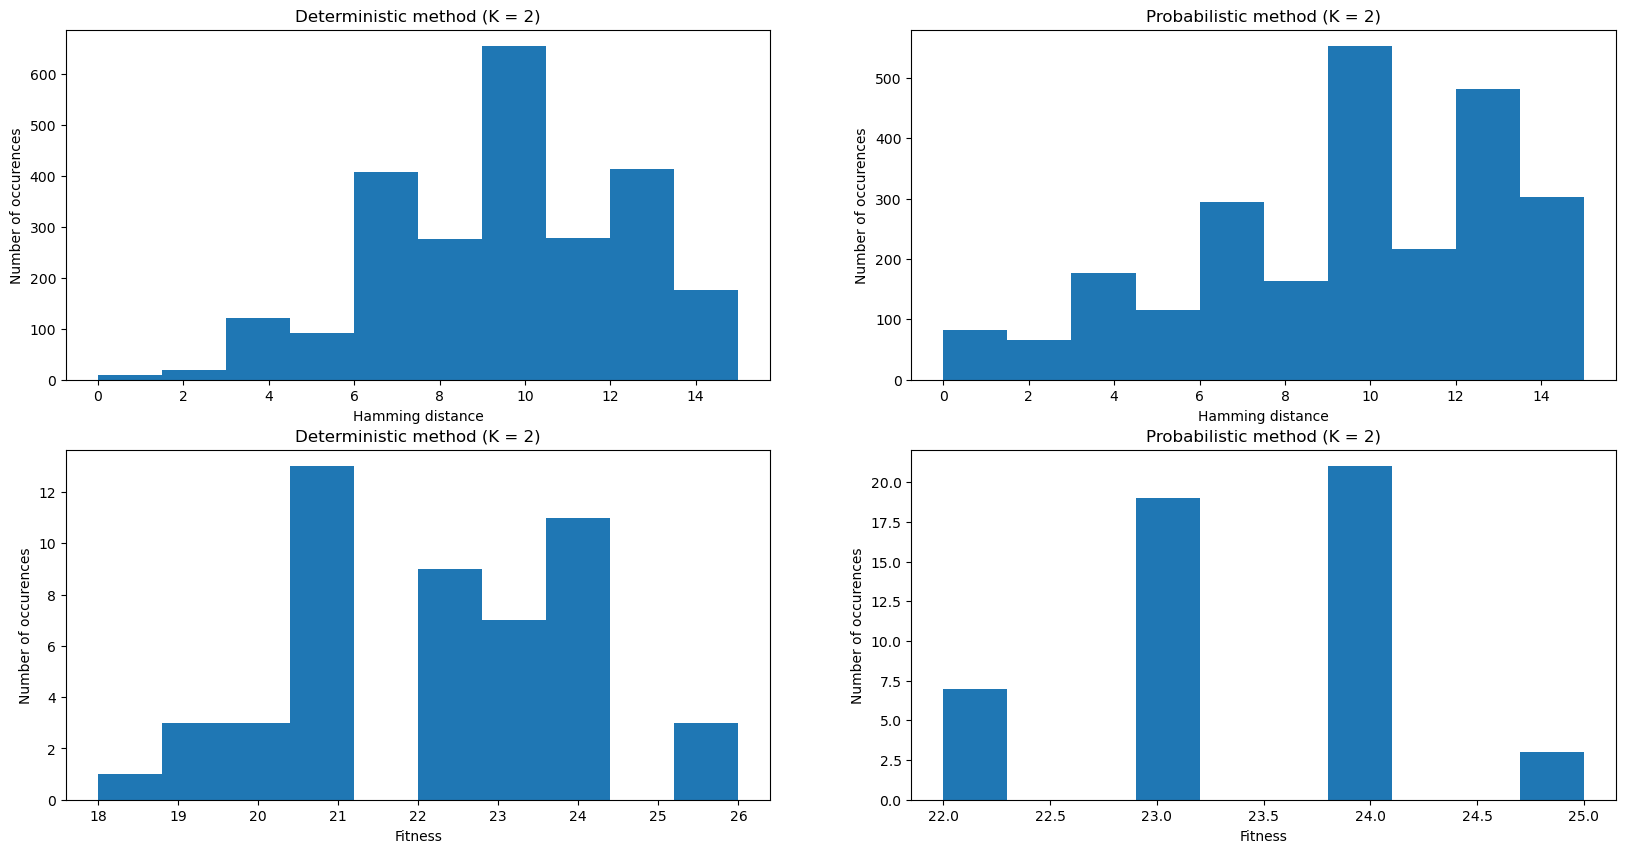

In [7]:
## TODO : Plot and analyze pairwise hamming distances for all methods and K values

for K in range(3):
    y_1 = np.array(deterministic_samples[K])[:, 0]
    y_2 = np.array(probabilistic_samples[K])[:, 0]
    assert len(y_1) == len(y_2)
    fitness_1 = np.array(deterministic_samples[K])[:, 1].astype(int)
    fitness_2 = np.array(probabilistic_samples[K])[:, 1].astype(int)
    histogram_1 = []
    histogram_2 = []
    for i in range(len(y_1)):
        for j in range(len(y_2)):
            if i != j:
                histogram_1.append(hamming_distance(y_1[i], y_1[j]))
                histogram_2.append(hamming_distance(y_2[i], y_2[j]))
    # Health check on Hamming distances... As we have 21 bits, the Hamming distance must be less or equal to 21
    assert max(histogram_1) < 21
    assert max(histogram_2) < 21
    plt.figure(figsize=(20,10))
    plt.subplot(2, 2, 1)
    plt.title(f"Deterministic method (K = {K})")
    plt.xlabel("Hamming distance")
    plt.ylabel("Number of occurences")
    plt.hist(histogram_1)
    plt.subplot(2, 2, 2)
    plt.title(f"Probabilistic method (K = {K})")
    plt.xlabel("Hamming distance")
    plt.ylabel("Number of occurences")
    plt.hist(histogram_2)
    plt.subplot(2, 2, 3)
    plt.title(f"Deterministic method (K = {K})")
    plt.ylabel("Number of occurences")
    plt.xlabel("Fitness")
    plt.hist(fitness_1)
    plt.subplot(2, 2, 4)
    plt.title(f"Probabilistic method (K = {K})")
    plt.ylabel("Number of occurences")
    plt.xlabel("Fitness")
    plt.hist(fitness_2)
    plt.show()

In [8]:
## TODO : Describe and discuss the behaviour and the performance (in terms of the quality of the solutions) of each exploration method.

We want to compare the two methods: deterministic and probabilistic.

For the method deterministic, we can see that when the optimum result is simple, the method will find it, as we can see when K = 0.
In fact, when K = 0, as $f_0(0) = 2$ and $f_0(1) = 1$, the maximum is the sequence with only $0$.
The deterministic method found this result with a rate of success of 100% on 50 solutions. So this method give good results for simple problems.

However, when the complexity of the optimum solution is less simple, this method can be very bad... For instance, suppose that whe have multiple local solutions... The deterministic method can be blocked in a local solution because it searchs only the neighbours and compared to the neighbours, the solution is optimal but not globaly.

So the deterministic method has a good quality of solution for simple problems, but can also give bad solutions when we increase complexity of problems, and we can see it when looking at the Hamming distance when K = 2: the deterministic method found less optimum number than the probabilistic method. So probabilistic method is good for complex problems, but for simple problems, as we can see, the probabilistic method doesn't find always the correct solution and is less efficient than the deterministic method.

When we look at the execution time on Jupyter Notebook, we can see that probabilistic method takes about 10 seconds whereas deterministic method takes about 1 second... It means that the probabilistic method give better results for complex problems, but is more time-consumming than deterministic method.

In [9]:
## TODO : Answer the questions from TP 

1. What is the roughness of the landscape ?

    The roughness of the landscape is given by the variance of the fitness.
    We can observe that when K increase, the roughness increase also because we have more optimal solutions found for deterministic method and more solutions with probabilistic method.

2. What is the research space of the employed optimization methods ?

    The research space of the employed optimization methods is given by the generated sequences of bites '0010010110100', '1100101001010' etc... that "encode" the heigh of the landscape through the computation of the fitness for each sequence generated.

3. How are the two methods different ?

    The two method are different, as explained above. The deterministic method is good for simple problem, as we can see on histograms for K = 0: the optimum solution is found each time whereas the probabilistic method doesn't find the optimal solution each time.

    However, the deterministic method is not good for more complex problems because when K = 2, there are more solutions returned than for probabilistic method because the deterministic method will be blocked in local solution, what prevents finding the global solution whereas the probabilistic method is not blocked in local solutions due to the random choose of the neighbor to continue the search.

    The deterministic method is faster than the probabilistic method because probabilistic method need a lot of iterations to approach the optimum solution. And we can see that for K = 1, the solutions are something equivalent between the two methods, but in the time execution for the computation of each K, deterministic method takes about 1 second whereas probabilistic method takes about 10 seconds.

4. What is the neighborhood of an element of the research space ?

    The neighborhood of an element of the research space is the set of all sequences that differs with only 1 bit from the current sequence.

5. Is the solution of the optimization an element belonging to the research space or the fitness space ?

    The solution of the optimization give an element into fitness space, which is in our case the heigh of the landscape. As we search the greatest mountain in our landscape, we are searching on the heigh of the landscape given by fitness space.
    The research space is like coordinate of the point and the fitness space is like the heigh of the given coordinates.